# Phase 0 : Use Case


# Cas d’usage : Estimation automatique du prix de vente pour une plateforme immobilière en ligne

## Problème métier

L’objectif principal de notre plateforme est de permettre à un **propriétaire particulier** souhaitant vendre son bien de connaître immédiatement une **estimation objective de son prix**. Cette estimation permet :

* D’instaurer **confiance** chez le vendeur.
* De **réduire les délais de vente** en affichant un prix réaliste dès le départ.
* D’**automatiser** le processus pour limiter la mobilisation de ressources humaines coûteuses.

Dans ce cadre, nous intégrons un **modèle de machine learning** directement dans notre interface, permettant à l’utilisateur d’obtenir une **estimation instantanée** dès qu’il renseigne les caractéristiques de son bien.

---

## Rôle des données

Le jeu de données Kaggle *House Prices: Advanced Regression Techniques* constitue une base réaliste pour construire ce système :

* Il contient **79 variables descriptives** (superficie, nombre de pièces, quartier, qualité des matériaux, etc.) et un prix de vente final.
* Il reflète fidèlement les données que notre plateforme peut collecter via un formulaire rempli par l’utilisateur.

Ces données seront utilisées pour entraîner notre modèle à **prédire un prix à partir de caractéristiques connues**. Pour rester fiable, le modèle sera mis à jour régulièrement avec **de nouvelles ventes enregistrées** sur la plateforme.

---

## Acteurs concernés

1. **Vendeurs particuliers**

   * Utilisent l’outil pour obtenir une estimation fiable et gratuite.
   * Décident ensuite de mettre leur bien en ligne avec plus de sérénité.

2. **Plateforme**

   * Propose une **expérience utilisateur innovante**.
   * Génère des leads qualifiés via l’usage de l’outil d’estimation.
   * Réduit les allers-retours de négociation.

3. **Équipe Data Science**

   * Conçoit, teste, valide et surveille le modèle.
   * S’appuie sur le cycle **CRISP-ML** pour garantir la robustesse et l’évolutivité du système.

---

## Intégration du modèle dans le processus métier

* Avant : le vendeur doit consulter un agent ou faire une estimation manuelle via comparaison ou intuition.
* Après : en quelques clics, il renseigne les informations sur son bien et obtient une **fourchette de prix automatisée** (ex. : "entre 260 000 € et 280 000 €").

Cela améliore l’expérience client, limite les frictions et **valorise la data comme avantage compétitif**.

---

## Objectifs business

| Objectif                              | Description                                                                          |
| ------------------------------------- | ------------------------------------------------------------------------------------ |
| Générer des leads                     | En fournissant une estimation gratuite, on attire des vendeurs sur notre plateforme. |
| Réduire les délais de vente           | Un bon positionnement tarifaire favorise une vente rapide.                           |
| Augmenter la satisfaction utilisateur | En proposant un outil rapide et fiable.                                              |
| Réduire les coûts internes            | Moins de besoins d’agents ou d’experts mobilisés.                                    |
| Innover et se différencier            | Proposer un service basé sur des techniques de machine learning modernes.            |

---

## Approche ML envisagée

1. **Modèles testés** : Régressions (linéaire, Lasso, Ridge), Arbres de décision, Random Forest, Gradient Boosting, XGBoost.
2. **Pipeline** : Nettoyage, encodage, normalisation, sélection de features.
3. **Évaluation** : RMSE, RMSLE (notamment car recommandé pour ce challenge).
4. **Validation croisée** : Utilisation de K-Fold pour limiter l’overfitting.
5. **Hyperparamètres** : Grid Search, Random Search ou méthode bayésienne selon le modèle.

---

## Étapes CRISP-ML suivies

| Phase                  | Action                                                                                                               |
| ---------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Idéation**           | Compréhension du problème métier et de l’opportunité commerciale.                                                    |
| **Data Understanding** | Exploration des variables les plus informatives (ex. : quartier, superficie, qualité).                               |
| **Design**             | Création d’un pipeline sklearn prêt à transformer `train.csv` et `test.csv`.                                         |
| **Model Engineering**  | Test de plusieurs modèles et tuning des hyperparamètres.                                                             |
| **Evaluation**         | Sélection du meilleur modèle pour la plateforme, interprétation métier.                                              |
| **Operation**          | Soumission sur Kaggle, puis intégration potentielle dans la plateforme avec monitoring, MLOps et contrôle de dérive. |

---

## Conclusion

Notre use case illustre une **application concrète du machine learning au service du business**. Grâce à l’outil d’estimation :

* Le vendeur bénéficie d’un service rapide, fiable et rassurant.
* La plateforme optimise son acquisition client et ses performances internes.
* Le modèle peut évoluer avec les tendances du marché et rester pertinent.



# Phase 1 : Phase d'idéation

## 1.1 Analyse du besoin métier et préparation des données

La mise en place d'un modèle d'estimation immobilière pour une plateforme en ligne implique d’abord une étape préliminaire cruciale consistant à préciser les attentes commerciales, à identifier précisément les indicateurs de performance du modèle, et à vérifier rigoureusement la qualité et la pertinence des données disponibles.

Dans ce contexte précis, cette étape garantit que notre solution automatisée répondra aux exigences des utilisateurs en fournissant une évaluation immobilière immédiate et objective. Elle permet également de confirmer que les informations récoltées via notre formulaire en ligne sont suffisamment qualitatives pour construire un modèle prédictif robuste et pertinent pour nos utilisateurs particuliers.


In [ ]:
!pip install statsmodels
!pip install shap
!pip install -r requirements.txt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot

import math

In [ ]:
plt.style.use('seaborn-v0_8') # pretty matplotlib plots

In [ ]:
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')

### 1.1.1 Aperçu des données

In [53]:
train_raw.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### 1.1.1.4 Identification de la cible du modèle

Lorsqu’on débute une analyse prédictive, il est essentiel de comprendre précisément la variable à prédire. Dans notre cas, il s'agit du montant auquel un bien immobilier sera vendu, désigné par la variable **SalePrice**.

Pour répondre spécifiquement au besoin, notre modèle exploitera diverses caractéristiques immobilières telles que la superficie, la qualité des matériaux ou encore l’emplacement, afin de prévoir précisément cette valeur finale.

In [54]:
# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Ce résumé chiffré ne permet pas une interprétabilité visuelle directe, mais indique néanmoins que la majorité des biens sont vendus dans une fourchette de prix assez resserrée : environ 130 000 pour le premier quartile, une médiane à 163 000, une moyenne à 180 000 et un troisième quartile autour de 214 000. Cette différence entre médiane et moyenne révèle la présence de quelques biens particulièrement coûteux, qui influencent la moyenne vers des valeurs supérieures.

Ce type de situation est fréquent dans l'immobilier, où un grand nombre de biens se concentrent dans une tranche de prix moyenne, tandis que quelques propriétés d’exception font nettement grimper la moyenne.

#### 1.1.1.5 Visualisation de la distribution de la variable cible

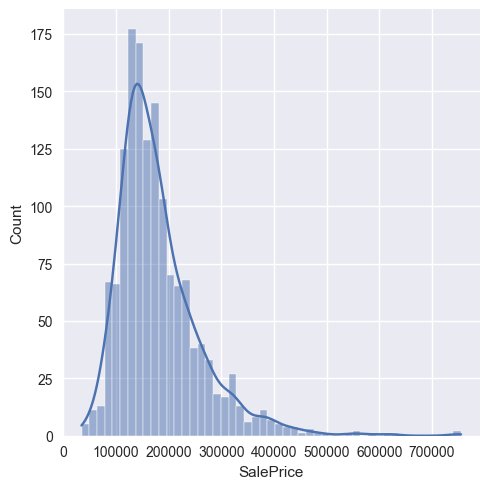

In [57]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

La distribution observée présente clairement une asymétrie marquée. Afin de confirmer statistiquement qu'elle diffère d'une distribution normale, un test d’hypothèse rapide doit être réalisé.

Dans notre scénario, l'hypothèse initiale suppose que la variable **Prix de vente** suit une distribution normale dans la population d’origine. Pour vérifier cette hypothèse, nous allons recourir au *test statistique de Shapiro-Wilk* qui, en cas de rejet, validera que les données ne sont pas distribuées normalement.

The assocated p-value is : 3.2061412312022114e-33
With a threshold α = 0.05, we reject the null hypothesis


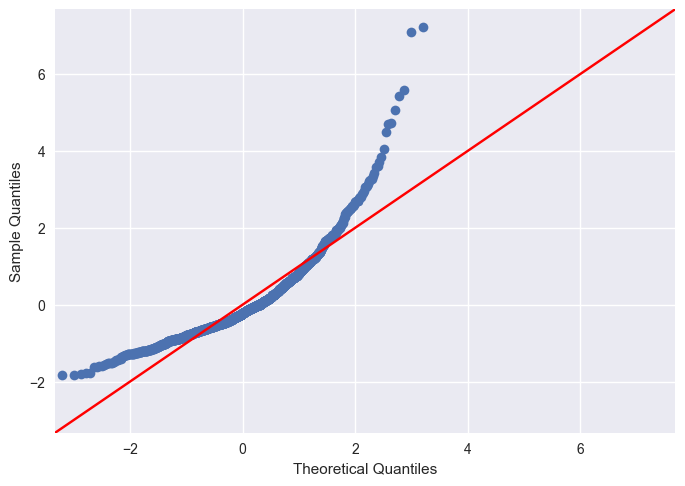

In [58]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha :
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else :
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')

qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

Le résultat du *test de Shapiro-Wilk* et l’analyse du **Q-Q plot** indiquent clairement que les données ne suivent pas une distribution normale. Ce constat appuie la nécessité de transformer la variable cible via une échelle logarithmique. Cette opération permet de régulariser la dispersion des valeurs et réduit l’impact disproportionné des propriétés très coûteuses sur le modèle.

#### 1.1.1.6 Transformation logarithmique de la variable cible

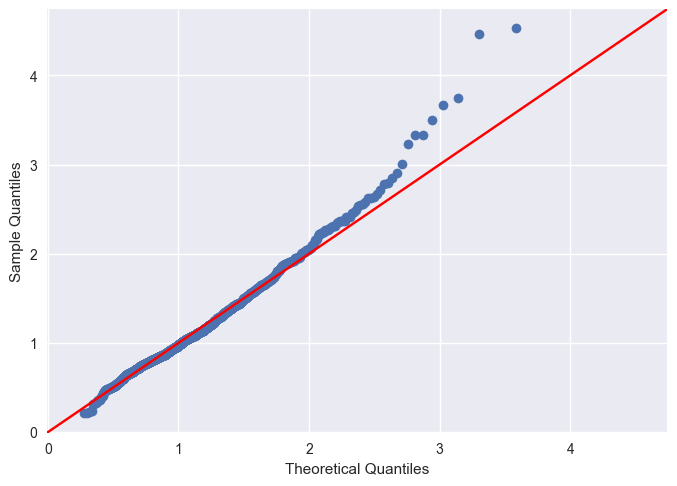

In [59]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

#### 1.1.1.7 Réduction de l’influence des valeurs extrêmes par log-transformation

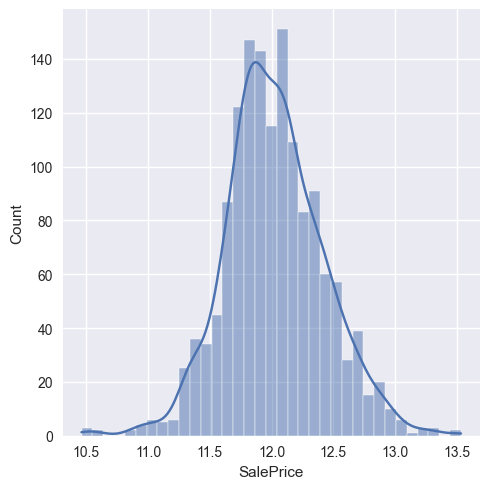

In [60]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

L'histogramme de la variable **SalePrice** après l'utilisation du logarithme `log1p`est proche d'une courbe normale. La forme est désormais symétrique et centré autour d'un pic (vers 12). Et le logarithme a permis une réduction de l'influence des valeurs extrêmes.

### 1.1.2 Variables indépendantes

Dans le jeu de données, trois types de variables sont présents : qualitatives, quantitatives et temporelles.

In [ ]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish',
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

### 1.1.3 Fusion des jeux d’entraînement et de test pour un nettoyage unifié

In [ ]:
data_raw = pd.concat([train_raw, validation_raw])

### 1.2 Imputation des valeurs manquantes

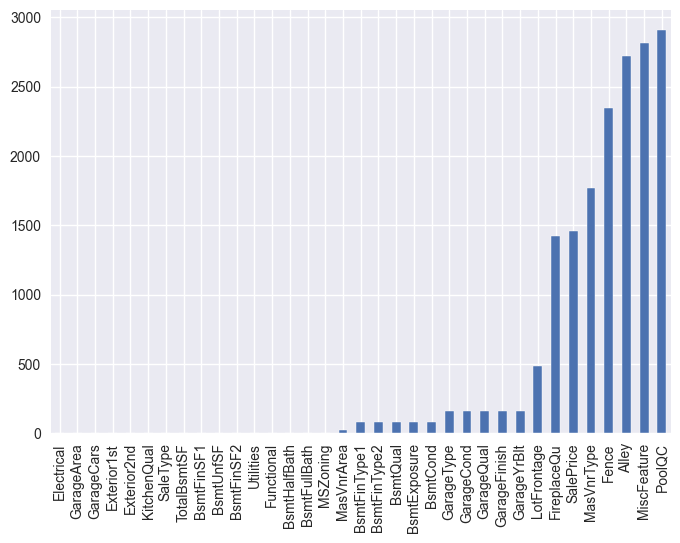

In [61]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]

    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()

        plt.show()

plot_missing(data_raw)

Nous observons que le fichier de test (test.csv) contient plus de données manquantes que celui d’entraînement (train.csv), ce qui reflète typiquement la réalité opérationnelle. Par exemple, la caractéristique **TotalBsmtSF** (surface totale du sous-sol) est toujours complète pour les biens déjà vendus (train.csv), mais comporte des lacunes pour ceux encore à évaluer (test.csv).

Ce phénomène illustre une problématique courante : les biens déjà vendus disposent souvent de dossiers détaillés, tandis que les nouvelles entrées ou les biens en cours d'estimation peuvent présenter des informations partielles.

Pour gérer efficacement cette situation, nous avons décidé d'associer temporairement les jeux d'entraînement et de test pendant l'exploration initiale. Ce procédé assure un traitement homogène des données absentes et garantit un prétraitement stable pour toutes les futures évaluations effectuées par l’agence.

### 1.2.1 Variables quantitatives

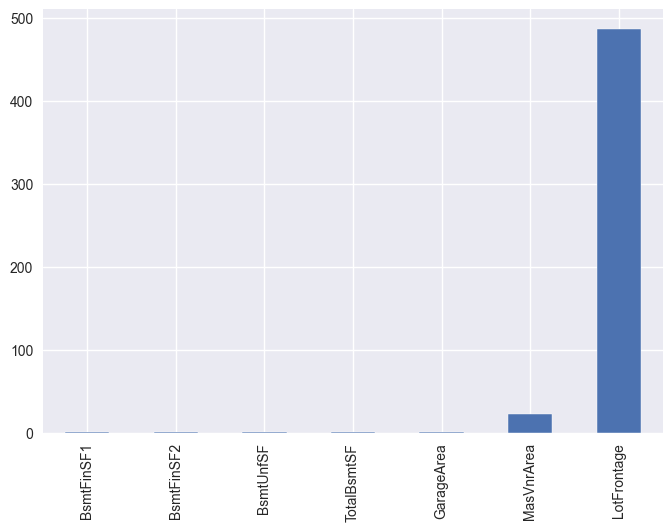

In [62]:
# Affichage des variables manquantes
plot_missing(data_raw[quantitative])

La stratégie qui fait le plus de sens est de remplir les valeurs manquantes par zéro (0). En effet, les valeurs manquantes indiquent qu'elles ne sont pas présentes dans le bien immobilier, et donc qu'elles sont égales à zéro. Par exemple, si un bien n'a pas de garage, la surface du garage est nulle. De même, si un bien n'a pas de sous-sol, la surface du sous-sol est également nulle.

In [ ]:
# Pour les variables quantitatives, nous allons remplir les colonnes avec 0
def fill_missing_with_constant(data, columns, constant):

    data_clean = data.copy()

    for c in columns :

        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)

    return data_clean

### 1.2.2 Variables qualitatives

La stratégie qui fait le plus de sens pour les variables qualitatives est de remplir les valeurs manquantes par 'NA', comme on le ferait en Business Intelligence.

In [ ]:
plot_missing(data_raw[qualitative])

_Nous n'avons pas besoin de définir une fonction particulière pour cela car nous utilisons la fonction fill_missing_with_constant définie précédemment._

### 1.2.3 Variables temporelles

Nous pouvons voir que la seule variable temporelle qui a des valeurs manquantes est **GarageYrBlt**, probablement parce que la maison n'a pas de garage. Ainsi, remplaçons cette date par **YearBuilt**, ce qui a du sens d'un point de vue métier.

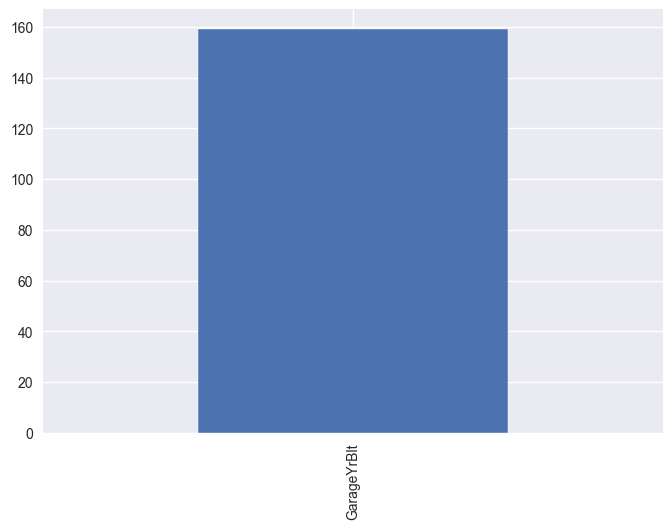

In [63]:
plot_missing(data_raw[date])

In [ ]:
# Pour les variables temporelles, nous allons remplir les valeurs manquantes en utilisant les valeurs d'une autre colonne
def fill_missing_with_column(data, missing, column) :

    data_clean = data.copy()

    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])

    return data_clean

## 1.3 Transformation de base

Étant donné que les ventes vont de 2006 à 2010, il serait logique de calculer le nombre d'années depuis la construction de la maison, sa rénovation, etc.

In [ ]:
def compute_differences_to_year_sold(data) :

    data_clean = data.copy()

    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']

    return data_clean

## 1.4 Exécution du processus de nettoyage

In [64]:
def clean(data) :

    data_clean = data.copy()

    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)

    return data_clean

data_clean = clean(data_raw)

data_clean.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


## 1.5 Analyse exploratoire des données (EDA)

Nous allons maintenant effectuer l'EDA et réfléchir à la manière dont nous allons résoudre ce cas. Nous avons deux types de variables, les variables catégorielles et les variables numériques. De plus, nous devons diviser notre ensemble de données nettoyé en un ensemble d'entraînement et un ensemble de validation comme auparavant.

In [ ]:
categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

numeric = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
           'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
           'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
           'PoolArea', 'MiscVal', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Split of the clean dataset into train & validation
train_clean = data_clean[data_clean.index.isin(train_raw.index)]
validation_clean = data_clean[data_clean.index.isin(validation_raw.index)]

### 1.5.1 Analyse des variables numériques

Il est assez standard de regarder la corrélation entre chaque variable numérique et notre variable cible, c'est-à-dire le logarithme de SalePrice. Attention à ne pas effectuer une corrélation avec SalePrice lui-même, car le lien n'est probablement pas linéaire comme nous l'avons vu précédemment.

In [ ]:
def correlation(y, X, features, method = 'pearson'):

    cor = pd.DataFrame()
    cor['feature'] = features

    cor['correlation_coef'] = [X[f].corr(y, method = method) for f in features]
    cor['correlation_coef'] = cor['correlation_coef'].fillna(0)

    cor = cor.sort_values('correlation_coef', ascending = False)

    plt.figure(figsize=(10, 0.25*len(features)))
    sns.barplot(data = cor, y = 'feature', x = 'correlation_coef', orient = 'h')

    return cor

Voyons ensuite les corrélations entre les variables numériques et le logarithme de SalePrice sur l'ensemble de données train_clean.

In [ ]:
cor = correlation(target, train_clean, numeric, method = 'pearson')

La valeur de corrélation elle-même peut être trompeuse, il faut tracer les nuages de points. Traçons tous les nuages de points pour ces caractéristiques numériques.

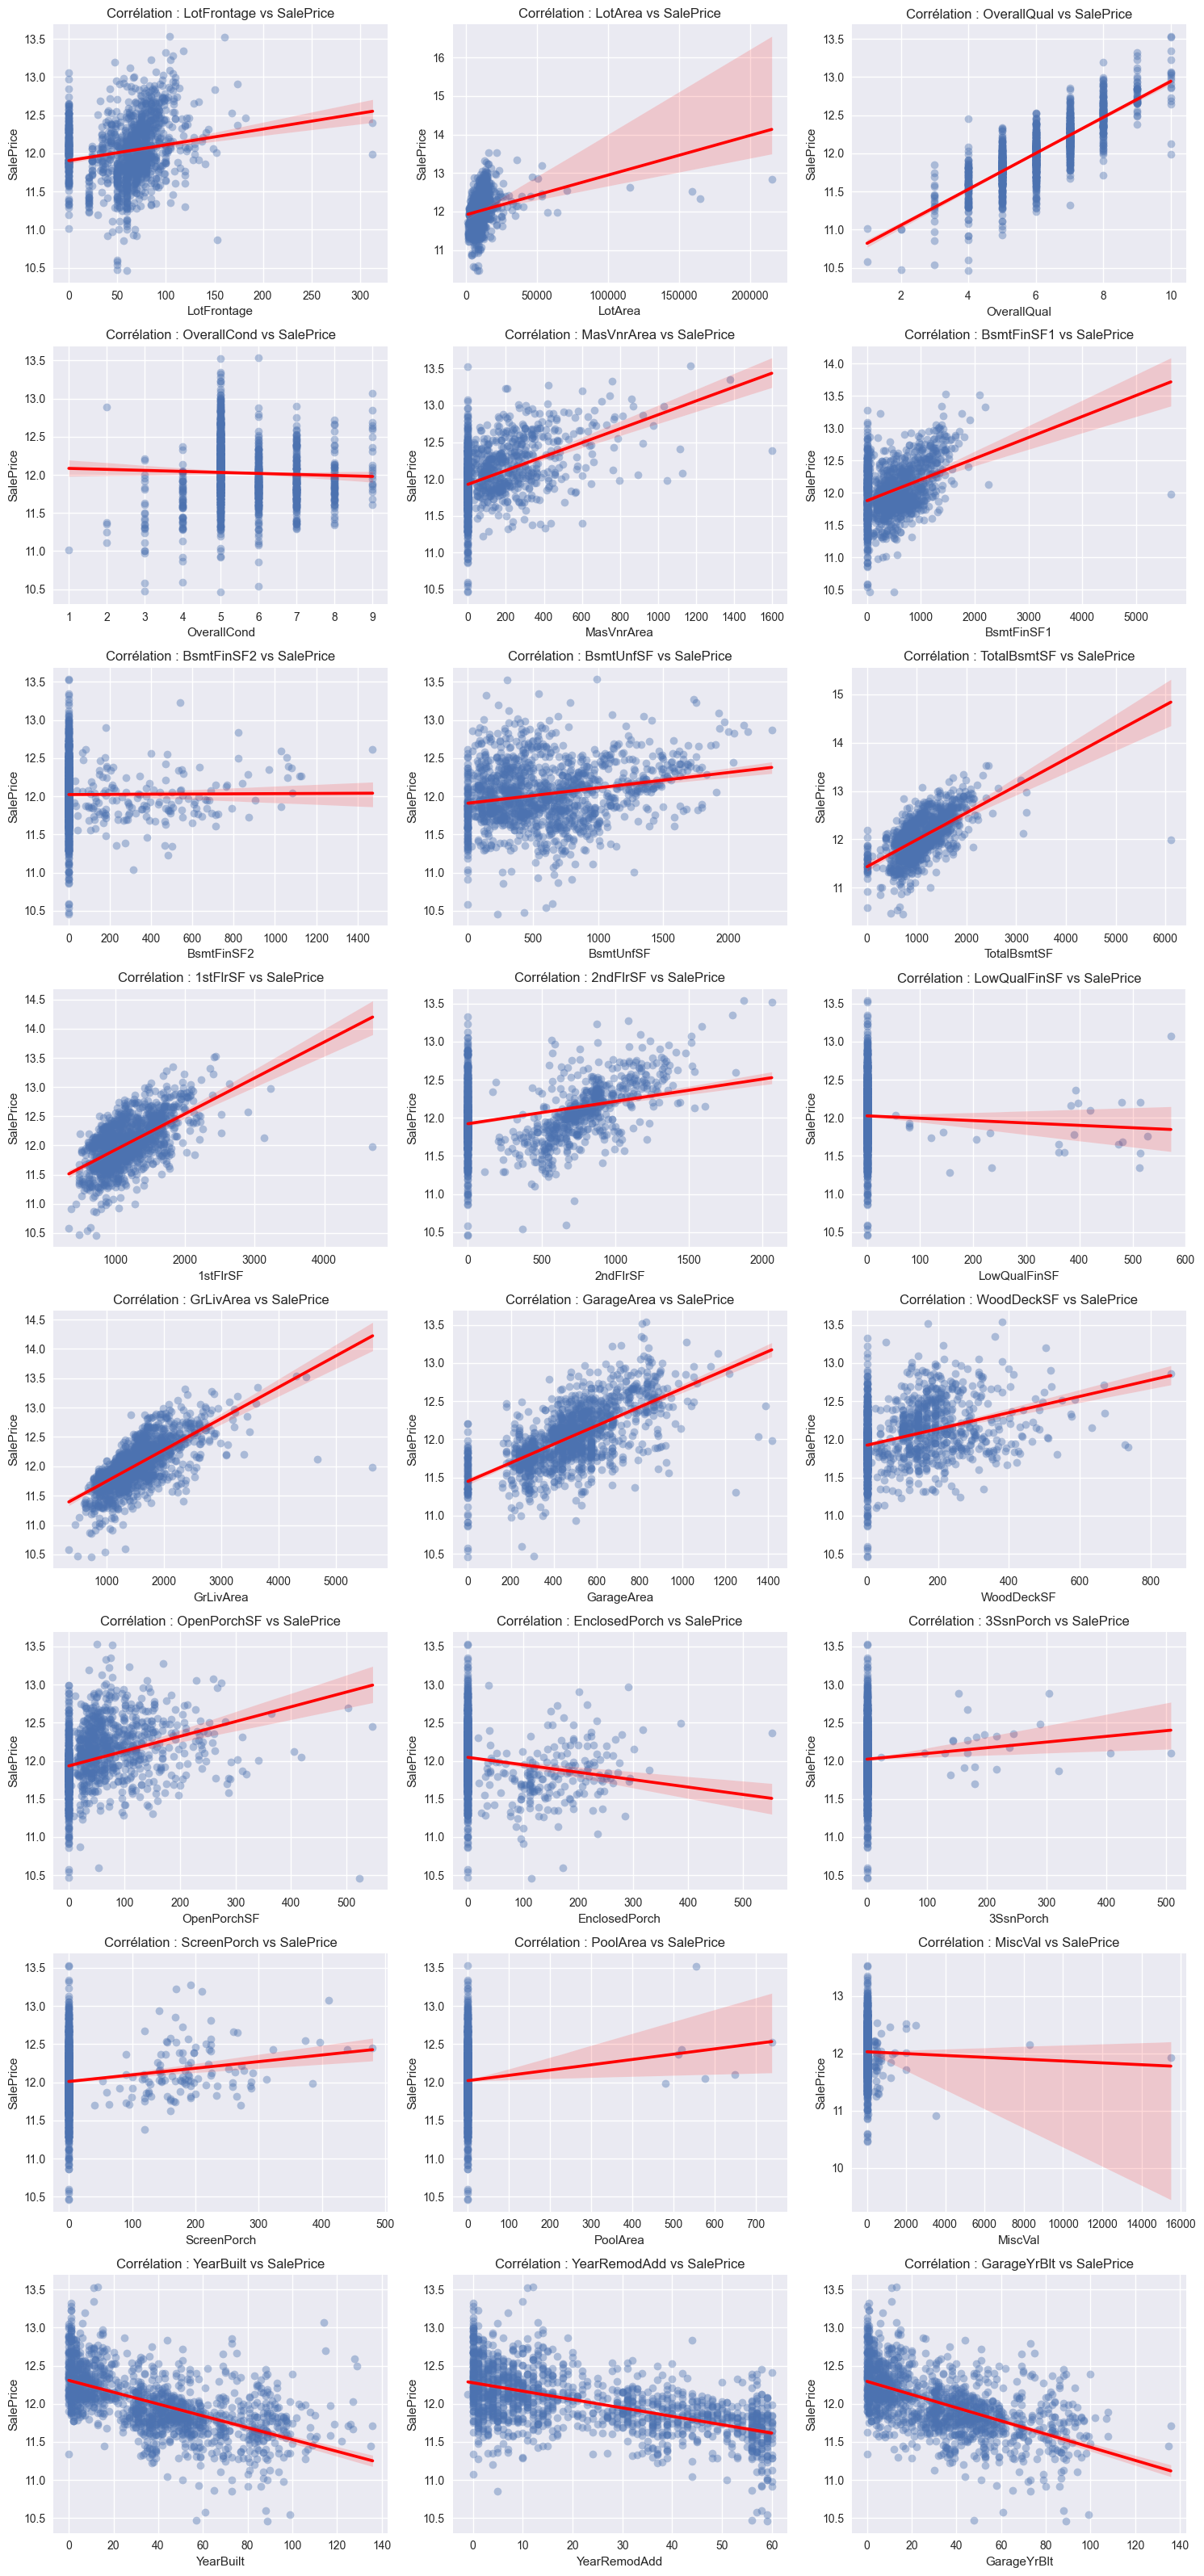

In [65]:
def scatter_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        x = X[f]
        sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
        axes[i].set_title(f'Corrélation : {f} vs {y.name}')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

scatter_plots_grid(target, train_clean, numeric)

Les 24 graphiques présentés ci-dessus illustrent les relations entre diverses variables numériques et le prix de vente (SalePrice, transformé en logarithme). Ces visualisations permettent d'identifier rapidement les variables ayant un impact significatif sur le prix et celles qui peuvent être exclues de notre modélisation.

### Variables avec une forte corrélation

| Variable |
|----------|
| OverallQual |
| GrLivArea |
| TotalBsmtSF |
| 1stFlrSF |
| GarageArea |

Ces variables présentent une relation linéaire claire et ascendante avec le prix de vente. Elles indiquent une tendance nette : une augmentation de leur valeur est associée à une hausse du prix de vente. Par conséquent, elles constituent des prédicteurs robustes à intégrer dans notre modèle.

### Variables avec une corrélation modérée

| Variable |
|----------|
| LotArea |
| MasVnrArea |
| WoodDeckSF |
| OpenPorchSF |
| ScreenPorch |
| PoolArea |

Bien que la tendance soit moins marquée pour ces variables, elles peuvent néanmoins apporter une valeur explicative supplémentaire, notamment lorsqu'elles sont combinées avec d'autres. Par exemple, la présence d'une piscine ou d'une terrasse peut contribuer à une estimation plus précise dans des contextes spécifiques.

### Variables avec peu ou pas de lien apparent

| Variable |
|----------|
| LotFrontage |
| OverallCond |
| BsmtUnfSF |
| BsmtFinSF2 |
| 2ndFlrSF |
| GarageYrBlt |
| YearBuilt |
| YearRemodAdd |

Ces variables montrent une dispersion importante ou une relation presque horizontale avec le prix de vente. Leur contribution semble limitée ou confuse, et elles pourraient être exclues du modèle ou retravaillées, par exemple, par encodage ou regroupement.

### Variables sans intérêt ou contre-productives

| Variable |
|----------|
| LowQualFinSF |
| EnclosedPorch |
| 3SsnPorch |
| MiscVal |

Ces variables présentent peu de valeurs non nulles et n'apportent aucun signal clair sur le prix de vente. Elles peuvent être considérées comme non pertinentes pour la prédiction et pourraient être exclues de l'analyse.

### 1.5.2 Analyse des variables catégorielles

Pour les variables catégorielles, nous ne pouvons pas effectuer de corrélation pour des raisons évidentes. Nous devons donc effectuer une ANOVA (https://fr.wikipedia.org/wiki/Analyse_de_variance) qui est le pendant dans le cas où nous voulons comprendre le lien entre une variable catégorielle et une variable numérique.

L'ANOVA (Analyse de Variance) est une méthode statistique qui permet de comparer les moyennes de plusieurs groupes pour déterminer s'il existe des différences significatives entre eux. Dans notre cas, nous allons l'utiliser pour évaluer si les différentes catégories d'une variable qualitative ont un impact significatif sur la variable numérique cible, le prix de vente (logarithme de SalePrice).

In [ ]:
def anova(y, X, features):

    anova = pd.DataFrame()
    anova['feature'] = features
    pvals = []

    for f in features:

        samples = []

        for cls in X[f].unique():

            s = y[X[f] == cls].values
            samples.append(s)

        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)

    anova['pval'] = pvals
    anova = anova.sort_values('pval')

    anova['disparity'] = np.log(1. / anova['pval'].values)

    sns.barplot(data = anova, x = 'feature', y = 'disparity')
    x = plt.xticks(rotation=90)

    return anova

anova = anova(target, train_clean, categorical)

Ce graphique, issu de l'analyse ANOVA, permet d'identifier les variables catégorielles qui différencient le plus les prix de vente selon leurs modalités.

Par exemple, des variables comme Neighborhood, ExterQual ou KitchenQual montrent une forte disparité entre les groupes, ce qui indique qu'elles ont un impact plus marqué que d'autres variables comme Street ou BsmtHalfBath.

Cependant, une forte disparité ne signifie pas forcément une grande influence directe sur le prix de vente, mais plutôt que la variable permet de mieux séparer les niveaux de prix entre ses catégories.

In [ ]:
def box_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        sns.boxplot(x=X[f], y=y, ax=axes[i])
        axes[i].set_title(f'Box plot {f} vs {y.name}')
        axes[i].tick_params(axis='x', rotation=90)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

box_plots_grid(train_clean['SalePrice'], train_clean, categorical)

# Phase 2 : Phase de design